In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv(r"C:\Users\hande\Downloads\buisness_data (3).csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (100, 7)


,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Columns:
['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region', 'Total_Sales']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB


In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Duplicate Rows:
0


In [5]:
df.describe()

,Quantity,Price,Total_Sales
count,100.000000,100.000000,100.000000
mean,4.780000,25808.510000,123650.480000
std,2.588163,13917.630242,100161.085275
min,1.000000,1308.000000,6540.000000
25%,2.750000,14965.250000,39517.500000
50%,5.000000,24192.000000,97955.500000
75%,7.000000,38682.250000,175792.500000
max,9.000000,49930.000000,373932.000000


# Data Cleaning & Preparation

In [8]:
# Check data types

print("Data Types:")
print(df.dtypes)

Data Types:
Date           object
Product        object
Quantity        int64
Price           int64
Customer_ID    object
Region         object
Total_Sales     int64
dtype: object


In [10]:
# Check missing values

print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


In [11]:
# Check duplicate records

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [12]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (100, 7)


In [13]:
# Check numerical columns

numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numeric_columns.tolist())

Numerical Columns:
['Quantity', 'Price', 'Total_Sales']


In [14]:
df.head()

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680


In [15]:
print("Final Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Final Dataset Shape: (100, 7)

Missing Values:
Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Duplicate Rows: 0


# Descriptive Statistics

In [16]:
# Select numerical columns
numeric_cols = ["Quantity", "Price", "Total_Sales"]

# Calculate mean
mean_values = df[numeric_cols].mean()

# Calculate median
median_values = df[numeric_cols].median()

# Calculate mode
mode_values = df[numeric_cols].mode().iloc[0]

print("MEAN:")
print(mean_values)

print("\nMEDIAN:")
print(median_values)

print("\nMODE:")
print(mode_values)

MEAN:
Quantity            4.78
Price           25808.51
Total_Sales    123650.48
dtype: float64

MEDIAN:
Quantity           5.0
Price          24192.0
Total_Sales    97955.5
dtype: float64

MODE:
Quantity          4.0
Price          1308.0
Total_Sales    6540.0
Name: 0, dtype: float64


In [17]:
# Calculate variance
variance_values = df[numeric_cols].var()

# Calculate standard deviation
std_values = df[numeric_cols].std()

print("VARIANCE:")
print(variance_values)

print("\nSTANDARD DEVIATION:")
print(std_values)

VARIANCE:
Quantity       6.698586e+00
Price          1.937004e+08
Total_Sales    1.003224e+10
dtype: float64

STANDARD DEVIATION:
Quantity            2.588163
Price           13917.630242
Total_Sales    100161.085275
dtype: float64


In [18]:
descriptive_stats = df[numeric_cols].describe().T

descriptive_stats["variance"] = df[numeric_cols].var()
descriptive_stats["mode"] = df[numeric_cols].mode().iloc[0]

descriptive_stats

,count,mean,std,min,25%,50%,75%,max,variance,mode
Quantity,100.0,4.78,2.588163,1.0,2.75,5.0,7.00,9.0,6.698586e+00,4.0
Price,100.0,25808.51,13917.630242,1308.0,14965.25,24192.0,38682.25,49930.0,1.937004e+08,1308.0
Total_Sales,100.0,123650.48,100161.085275,6540.0,39517.50,97955.5,175792.50,373932.0,1.003224e+10,6540.0


##### Initial Interpretation

The descriptive statistics provide an overview of the sales dataset.

The average quantity sold is 4.78 units, while the average price is 25,808.51. The average total sales value is 123,650.48.

The standard deviation of Total_Sales is relatively high compared with its mean, indicating substantial variation in sales values across transactions.

The median Total_Sales is 97,955.50, which is lower than the mean of 123,650.48. This suggests that some transactions with relatively high sales values may be influencing the average.

# Data Distribution Analysis

####  Data Distribution Analysis

Histograms and density plots are used to understand the distribution of Quantity, Price, and Total_Sales.

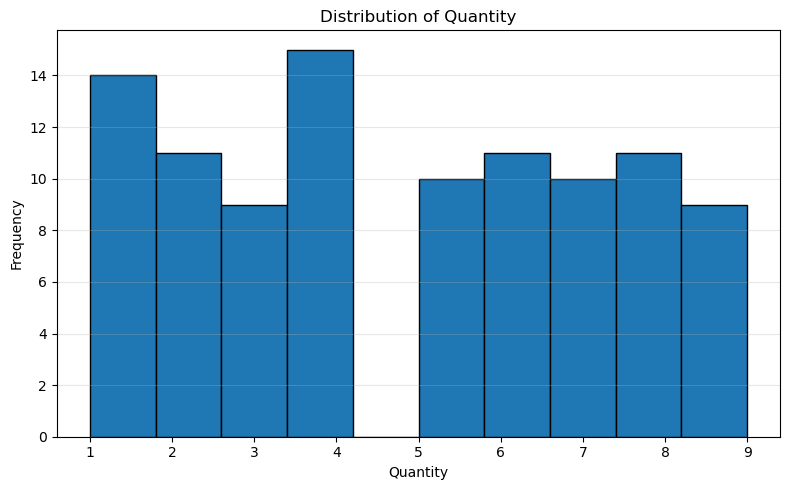

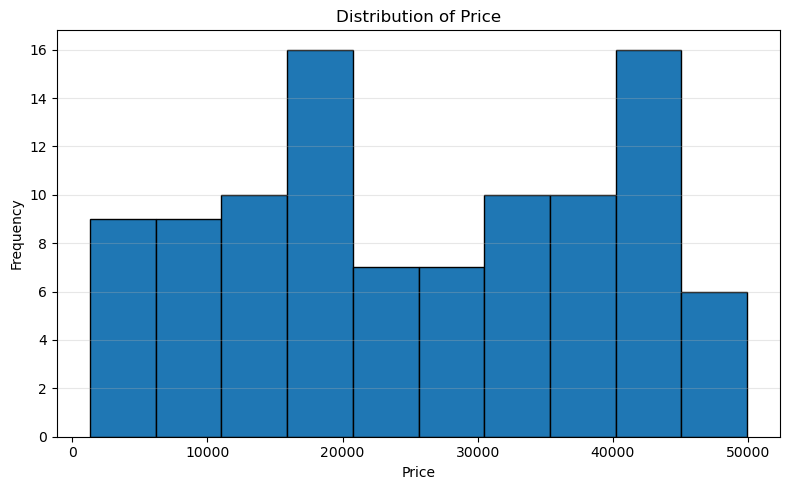

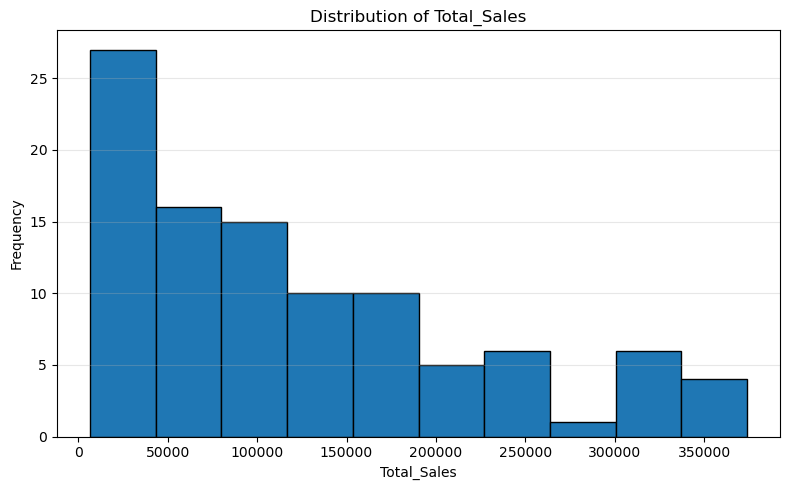

In [19]:
# Create histograms for numerical variables

numeric_cols = ["Quantity", "Price", "Total_Sales"]

for column in numeric_cols:
    plt.figure(figsize=(8, 5))
    
    plt.hist(df[column], bins=10, edgecolor="black")
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.grid(axis="y", alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"visualizations/{column}_histogram.png")
    plt.show()

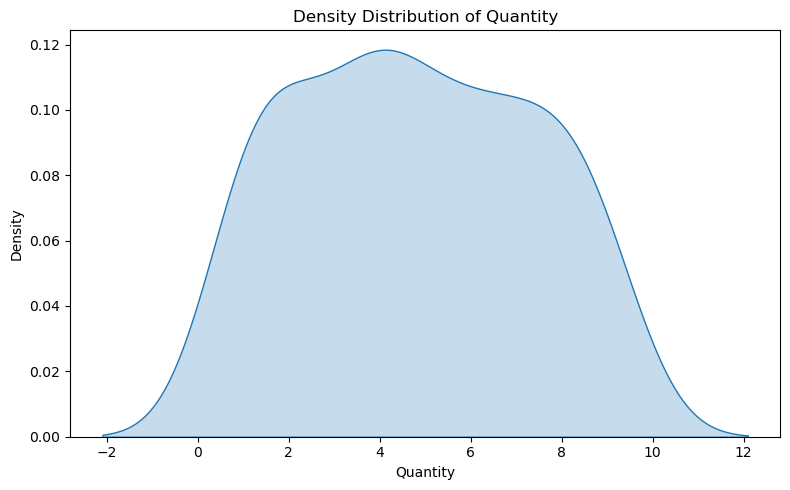

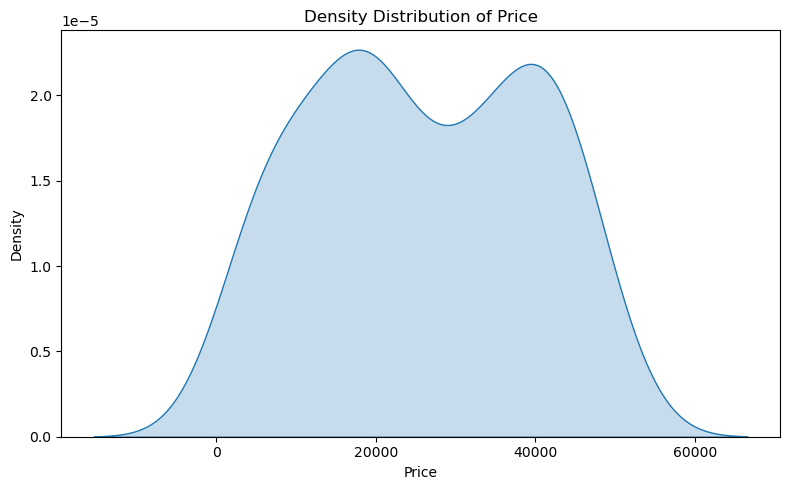

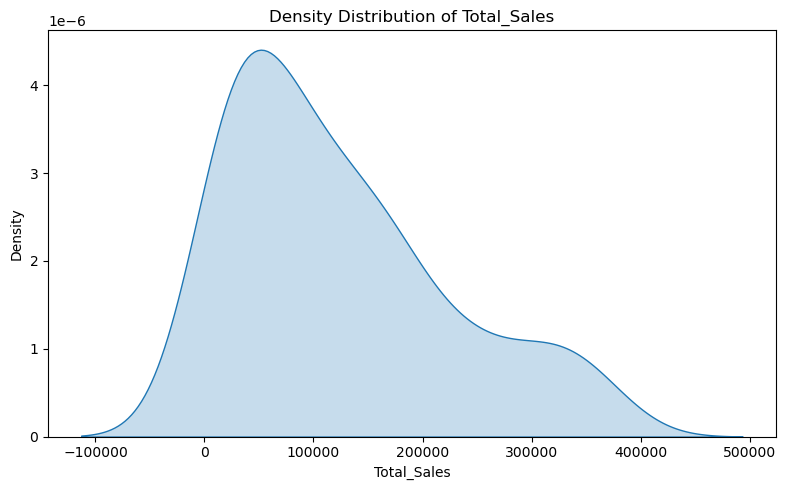

In [20]:
# Create KDE density plots

for column in numeric_cols:
    plt.figure(figsize=(8, 5))
    
    sns.kdeplot(data=df, x=column, fill=True)
    
    plt.title(f"Density Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Density")
    
    plt.tight_layout()
    plt.savefig(f"visualizations/{column}_kde.png")
    plt.show()

### Normality Test

The Shapiro-Wilk test is used to determine whether the numerical variables follow a normal distribution.

H₀: The data follows a normal distribution.

H₁: The data does not follow a normal distribution.

Significance level: α = 0.05

In [21]:
# Shapiro-Wilk normality test

for column in numeric_cols:
    statistic, p_value = stats.shapiro(df[column])
    
    print(f"\n{column}")
    print(f"Test Statistic: {statistic:.4f}")
    print(f"P-value: {p_value:.4f}")
    
    if p_value < 0.05:
        print("Result: Data is not normally distributed.")
    else:
        print("Result: Data is approximately normally distributed.")


Quantity
Test Statistic: 0.9304
P-value: 0.0001
Result: Data is not normally distributed.

Price
Test Statistic: 0.9475
P-value: 0.0006
Result: Data is not normally distributed.

Total_Sales
Test Statistic: 0.8989
P-value: 0.0000
Result: Data is not normally distributed.


# Correlation Analysis

In [22]:
# Calculate Pearson correlation matrix

numeric_cols = ["Quantity", "Price", "Total_Sales"]

correlation_matrix = df[numeric_cols].corr(method="pearson")

print("Pearson Correlation Matrix:")
print(correlation_matrix)

Pearson Correlation Matrix:
             Quantity     Price  Total_Sales
Quantity     1.000000  0.008014     0.688107
Price        0.008014  1.000000     0.646131
Total_Sales  0.688107  0.646131     1.000000


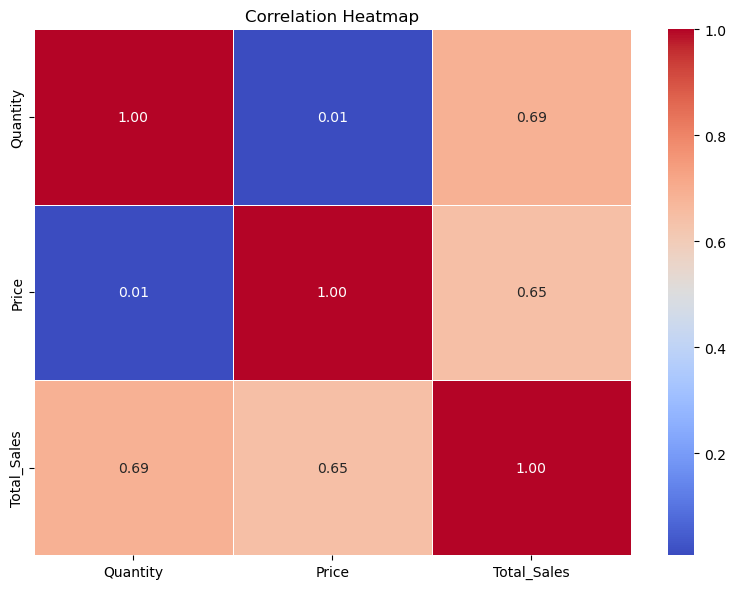

In [23]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig("visualizations/correlation_heatmap.png")
plt.show()

### Correlation Analysis Interpretation

The Pearson correlation analysis shows a strong positive relationship between Quantity and Total_Sales, with a correlation coefficient of 0.69. This indicates that transactions with higher quantities tend to have higher total sales.

Price and Total_Sales also have a strong positive correlation of 0.65, suggesting that higher-priced transactions tend to be associated with higher total sales.

The correlation between Quantity and Price is approximately 0.01, indicating almost no linear relationship between the quantity sold and the price.

Overall, Quantity and Price are both important variables associated with Total_Sales. However, correlation measures association and does not by itself prove a causal relationship.

In [24]:
print("Correlation with Total_Sales:")
print(correlation_matrix["Total_Sales"].sort_values(ascending=False))

Correlation with Total_Sales:
Total_Sales    1.000000
Quantity       0.688107
Price          0.646131
Name: Total_Sales, dtype: float64


# Hypothesis Test 1: One-Sample t-Test

##  Hypothesis Testing

### Hypothesis Test 1: One-Sample t-Test

Business Question:

Is the average Total_Sales significantly different from ₹100,000?

H₀: The population mean Total_Sales is equal to ₹100,000.

H₁: The population mean Total_Sales is different from ₹100,000.

Significance level: α = 0.05

Test: One-Sample t-Test

In [25]:
# One-sample t-test

benchmark = 100000

t_statistic, p_value = stats.ttest_1samp(
    df["Total_Sales"],
    benchmark
)

print("One-Sample t-Test")
print("------------------")
print(f"Benchmark Mean: {benchmark:,.2f}")
print(f"Sample Mean: {df['Total_Sales'].mean():,.2f}")
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Reject H₀.")
    print("The average Total_Sales is significantly different from ₹100,000.")
else:
    print("Result: Fail to reject H₀.")
    print("There is not enough evidence that the average Total_Sales differs from ₹100,000.")

One-Sample t-Test
------------------
Benchmark Mean: 100,000.00
Sample Mean: 123,650.48
t-statistic: 2.3612
p-value: 0.020172
Result: Reject H₀.
The average Total_Sales is significantly different from ₹100,000.


### Hypothesis Test 1 Interpretation

The one-sample t-test was conducted to determine whether the average Total_Sales differs significantly from the benchmark of ₹100,000.

The sample mean Total_Sales was ₹123,650.48. The test produced a t-statistic of 2.3612 and a p-value of 0.020172.

Since the p-value is less than the significance level of 0.05, the null hypothesis is rejected.

Therefore, there is statistically significant evidence that the average Total_Sales differs from ₹100,000. In this sample, the observed average sales are higher than the benchmark.

# Hypothesis Test 2: Independent Two-Sample t-Test

In [26]:
print("Regions in the dataset:")
print(df["Region"].unique())

print("\nNumber of records by region:")
print(df["Region"].value_counts())

Regions in the dataset:
['East' 'North' 'West' 'South']

Number of records by region:
Region
North    28
South    27
West     26
East     19
Name: count, dtype: int64


# Independent Two-Sample t-Test

### Hypothesis Test 2: Independent Two-Sample t-Test

Business Question:

Is the average Total_Sales significantly different between the North and South regions?

H₀: The mean Total_Sales of North and South regions is equal.

H₁: The mean Total_Sales of North and South regions is different.

Significance level: α = 0.05

Test: Independent Two-Sample t-Test

In [28]:
# Calculate average sales for North and South

north_sales = df[df["Region"] == "North"]["Total_Sales"]
south_sales = df[df["Region"] == "South"]["Total_Sales"]

print("North Region")
print("Number of records:", len(north_sales))
print("Average Total_Sales:", north_sales.mean())

print("\nSouth Region")
print("Number of records:", len(south_sales))
print("Average Total_Sales:", south_sales.mean())

North Region
Number of records: 28
Average Total_Sales: 142272.67857142858

South Region
Number of records: 27
Average Total_Sales: 138438.96296296295


In [29]:
# Independent two-sample Welch t-test

t_statistic, p_value = stats.ttest_ind(
    north_sales,
    south_sales,
    equal_var=False
)

print("Independent Two-Sample t-Test")
print("------------------------------")
print(f"t-statistic: {t_statistic:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Reject H₀.")
    print("There is a statistically significant difference in average Total_Sales between North and South.")
else:
    print("Result: Fail to reject H₀.")
    print("There is no statistically significant difference in average Total_Sales between North and South.")

Independent Two-Sample t-Test
------------------------------
t-statistic: 0.1299
p-value: 0.897152
Result: Fail to reject H₀.
There is no statistically significant difference in average Total_Sales between North and South.


### Hypothesis Test 2 Interpretation

An independent two-sample Welch t-test was conducted to determine whether there is a statistically significant difference in average Total_Sales between the North and South regions.

The North region had an average Total_Sales of ₹142,272.68, while the South region had an average Total_Sales of ₹138,438.96.

The test produced a t-statistic of 0.1299 and a p-value of 0.897152.

Since the p-value is greater than the significance level of 0.05, the null hypothesis is not rejected.

Therefore, there is insufficient statistical evidence to conclude that the average Total_Sales differs between the North and South regions.

# Hypothesis Test 3: One-Way ANOVA

### Hypothesis Test 3: One-Way ANOVA

Business Question:

Is there a statistically significant difference in average Total_Sales among East, North, South, and West regions?

H₀: The mean Total_Sales is equal across all four regions.

H₁: At least one region has a different mean Total_Sales.

Significance level: α = 0.05

Test: One-Way ANOVA

In [30]:
# Calculate average Total_Sales by region

regional_sales = df.groupby("Region")["Total_Sales"].agg(
    ["count", "mean", "std"]
)

print(regional_sales)

        count           mean            std
Region                                     
East       19  132612.578947   77107.089780
North      28  142272.678571   99202.384728
South      27  138438.962963  118423.995535
West       26   81689.307692   87843.595794


In [31]:
# Create sales groups for each region

east_sales = df[df["Region"] == "East"]["Total_Sales"]
north_sales = df[df["Region"] == "North"]["Total_Sales"]
south_sales = df[df["Region"] == "South"]["Total_Sales"]
west_sales = df[df["Region"] == "West"]["Total_Sales"]

# One-way ANOVA

f_statistic, p_value = stats.f_oneway(
    east_sales,
    north_sales,
    south_sales,
    west_sales
)

print("One-Way ANOVA")
print("--------------")
print(f"F-statistic: {f_statistic:.4f}")
print(f"p-value: {p_value:.6f}")

if p_value < 0.05:
    print("Result: Reject H₀.")
    print("There is a statistically significant difference in Total_Sales among the regions.")
else:
    print("Result: Fail to reject H₀.")
    print("There is no statistically significant difference in Total_Sales among the regions.")

One-Way ANOVA
--------------
F-statistic: 2.1644
p-value: 0.097237
Result: Fail to reject H₀.
There is no statistically significant difference in Total_Sales among the regions.


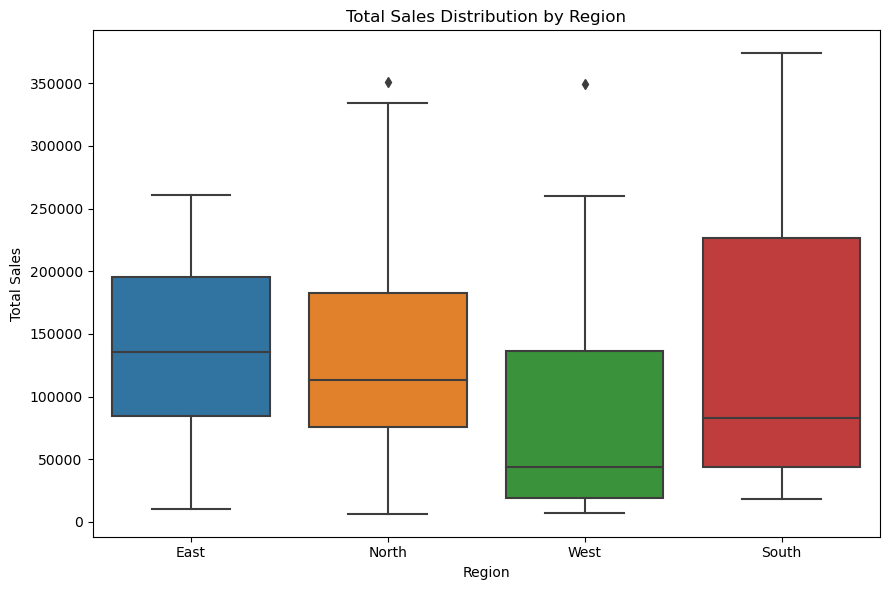

In [32]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="Region",
    y="Total_Sales"
)

plt.title("Total Sales Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("visualizations/regional_sales_boxplot.png")
plt.show()

### Hypothesis Test 3 Interpretation

A one-way ANOVA was conducted to determine whether there is a statistically significant difference in average Total_Sales among the East, North, South, and West regions.

The average Total_Sales was ₹132,612.58 for East, ₹142,272.68 for North, ₹138,438.96 for South, and ₹81,689.31 for West.

The ANOVA produced an F-statistic of 2.1644 and a p-value of 0.097237.

Since the p-value is greater than the significance level of 0.05, the null hypothesis is not rejected.

Therefore, there is insufficient statistical evidence to conclude that average Total_Sales differs significantly among the four regions. Although the West region has a lower observed average sales value than the other regions, the difference is not statistically significant at the 5% significance level.

##  Confidence Interval

A 95% confidence interval is calculated to estimate the range within which the population mean Total_Sales is expected to lie.

In [33]:
# Calculate 95% confidence interval for Total_Sales

sales = df["Total_Sales"]

sample_mean = sales.mean()
sample_std = sales.std()
sample_size = len(sales)

standard_error = sample_std / np.sqrt(sample_size)

confidence_level = 0.95
degrees_freedom = sample_size - 1

t_critical = stats.t.ppf(
    (1 + confidence_level) / 2,
    degrees_freedom
)

margin_of_error = t_critical * standard_error

lower_bound = sample_mean - margin_of_error
upper_bound = sample_mean + margin_of_error

print("95% Confidence Interval for Total_Sales")
print("-----------------------------------------")
print(f"Sample Mean: ₹{sample_mean:,.2f}")
print(f"Standard Error: ₹{standard_error:,.2f}")
print(f"Margin of Error: ₹{margin_of_error:,.2f}")
print(f"Lower Bound: ₹{lower_bound:,.2f}")
print(f"Upper Bound: ₹{upper_bound:,.2f}")
print(f"Confidence Interval: ₹{lower_bound:,.2f} to ₹{upper_bound:,.2f}")

95% Confidence Interval for Total_Sales
-----------------------------------------
Sample Mean: ₹123,650.48
Standard Error: ₹10,016.11
Margin of Error: ₹19,874.13
Lower Bound: ₹103,776.35
Upper Bound: ₹143,524.61
Confidence Interval: ₹103,776.35 to ₹143,524.61


### Confidence Interval Interpretation

A 95% confidence interval was calculated to estimate the population mean Total_Sales.

The sample mean Total_Sales is ₹123,650.48, with a margin of error of ₹19,874.13.

The resulting 95% confidence interval ranges from ₹103,776.35 to ₹143,524.61.

This means that the population mean Total_Sales is estimated to lie within this interval with 95% confidence, based on the sample data.

The relatively large margin of error indicates considerable variability in the sales values.

# Regression Analysis

###  Linear Regression Analysis

Linear regression is used to examine the relationship between Price and Total_Sales and determine how well Price can predict Total_Sales.

In [34]:
# Define independent and dependent variables

X = df[["Price"]]
y = df["Total_Sales"]

print("Independent Variable: Price")
print("Dependent Variable: Total_Sales")

Independent Variable: Price
Dependent Variable: Total_Sales


In [35]:
# Create and train linear regression model

model = LinearRegression()

model.fit(X, y)

# Predictions
y_pred = model.predict(X)

print("Linear regression model trained successfully!")

Linear regression model trained successfully!


In [36]:
# Regression coefficients

intercept = model.intercept_
coefficient = model.coef_[0]

r_squared = r2_score(y, y_pred)

print("Regression Results")
print("-------------------")
print(f"Intercept: ₹{intercept:,.2f}")
print(f"Coefficient: ₹{coefficient:,.2f}")
print(f"R-squared: {r_squared:.4f}")

Regression Results
-------------------
Intercept: ₹3,640.54
Coefficient: ₹4.65
R-squared: 0.4175


In [37]:
print(
    f"Regression Equation:\n"
    f"Total_Sales = {intercept:.2f} + ({coefficient:.2f} × Price)"
)

Regression Equation:
Total_Sales = 3640.54 + (4.65 × Price)


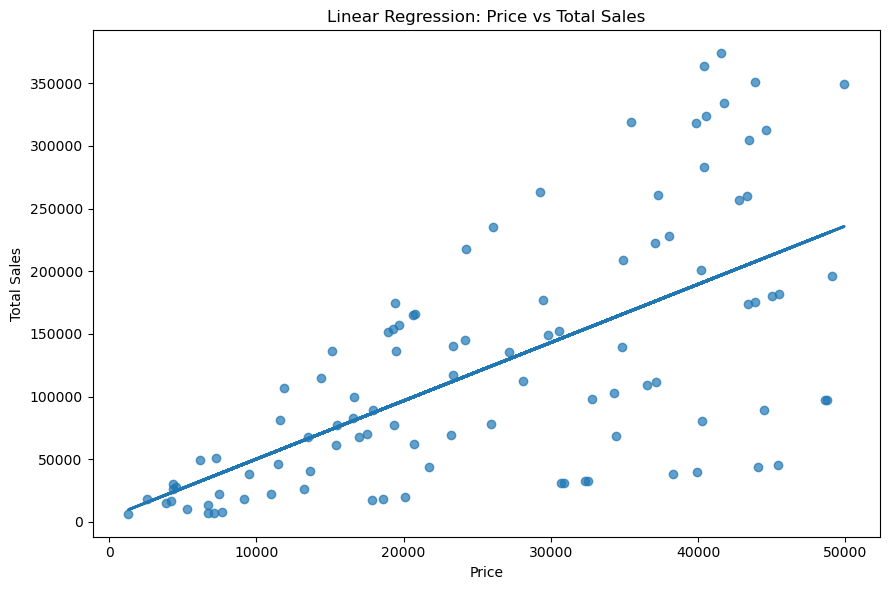

In [38]:
# Create regression plot

plt.figure(figsize=(9, 6))

plt.scatter(
    df["Price"],
    df["Total_Sales"],
    alpha=0.7
)

plt.plot(
    df["Price"],
    y_pred,
    linewidth=2
)

plt.title("Linear Regression: Price vs Total Sales")
plt.xlabel("Price")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("visualizations/regression_plot.png")
plt.show()

### Regression Analysis Interpretation

A simple linear regression model was developed to examine the relationship between Price and Total_Sales.

The regression equation is:

Total_Sales = 3640.54 + (4.65 × Price)

The coefficient of Price is 4.65, indicating that a one-unit increase in Price is associated with an estimated increase of approximately ₹4.65 in Total_Sales, based on this model.

The R-squared value is 0.4175, meaning that approximately 41.75% of the variation in Total_Sales is explained by Price in the linear regression model.

The remaining variation is explained by other factors that are not included in this model, such as Quantity, product characteristics, customer behavior, and regional differences.

Overall, the regression indicates a positive relationship between Price and Total_Sales, but Price alone does not fully explain sales variation.

# Final Business Insights

### Key Statistical Findings

1. Average Total_Sales was ₹123,650.48, while the median was ₹97,955.50. The difference between the mean and median indicates variation in transaction sales values.

2. The Shapiro-Wilk test showed that Quantity, Price, and Total_Sales were not normally distributed at the 5% significance level.

3. Quantity had a strong positive correlation with Total_Sales (r = 0.6881).

4. Price also had a strong positive correlation with Total_Sales (r = 0.6461).

5. The one-sample t-test found that average Total_Sales was significantly different from the ₹100,000 benchmark (p = 0.020172).

6. The independent two-sample t-test found no statistically significant difference between North and South regional sales (p = 0.897152).

7. The one-way ANOVA found no statistically significant difference in average Total_Sales across the four regions (p = 0.097237).

8. The 95% confidence interval for the population mean Total_Sales was ₹103,776.35 to ₹143,524.61, with a margin of error of ₹19,874.13.

9. The regression model showed a positive relationship between Price and Total_Sales, with an R-squared value of 0.4175.

### Business Recommendations

1. Focus on increasing sales quantity because Quantity has the strongest correlation with Total_Sales among the variables analyzed.

2. Monitor pricing strategies because Price has a positive relationship with Total_Sales, although Price alone does not explain all sales variation.

3. Avoid making major regional decisions based only on observed differences in average sales because the ANOVA did not find statistically significant differences among regions.

4. Investigate additional factors such as product type, customer characteristics, marketing expenditure, discounts, and seasonal trends to better explain sales performance.

5. Use statistical testing regularly when evaluating business performance instead of relying only on differences in average values.

6. Collect marketing expenditure data in future analysis so that the relationship between marketing investment and revenue can be statistically tested.